# Part 3: Basic Signal Operations

## 1. Overview
This document provides a technical discussion on **basic discrete-time signal operations** applied to a finite sequence $x[n] = \{2, -1, 3, 0, 4\}$, defined for $n = 0, 1, 2, 3, 4$.

The operations covered are:
- **Time Shift**: $y_1[n] = x[n-2]$ — shifts the sequence to the right by 2 samples
- **Time Reversal**: $y_2[n] = x[-n]$ — mirrors the sequence about $n = 0$
- **Signal Energy**: $E = \sum_n |x[n]|^2$ — total energy of the sequence

---

## 2. Python Implementation Code

The script below represents $x[n]$ as a dictionary of `{index: value}` pairs (to conveniently support negative indices after shifting/reversal), computes the three operations, and prints the resulting sequences and energy.

In [1]:
# PART 3: Basic Signal Operations
# x[n] = {2, -1, 3, 0, 4}, n=0 at value 2

import matplotlib.pyplot as plt

x = {0: 2, 1: -1, 2: 3, 3: 0, 4: 4}  # x[n] as {index: value}

def show(seq, name):
    # prints n and value pairs, sorted by n
    for n in sorted(seq.keys()):
        print(f"  n = {n} -> {seq[n]}")
    print()

print("x[n] (original):")
show(x, "x[n]")

# 1. Time Shift: y1[n] = x[n-2] -> shift right by 2
y1 = {n + 2: val for n, val in x.items()}
print("y1[n] = x[n-2]:")
show(y1, "y1")

# 2. Time Reversal: y2[n] = x[-n] -> mirror around n=0
y2 = {-n: val for n, val in x.items()}
print("y2[n] = x[-n]:")
show(y2, "y2")

# 3. Energy: E = sum |x[n]|^2
E = sum(abs(val) ** 2 for val in x.values())
print(f"Energy E = {E}")

x[n] (original):
  n = 0 -> 2
  n = 1 -> -1
  n = 2 -> 3
  n = 3 -> 0
  n = 4 -> 4

y1[n] = x[n-2]:
  n = 2 -> 2
  n = 3 -> -1
  n = 4 -> 3
  n = 5 -> 0
  n = 6 -> 4

y2[n] = x[-n]:
  n = -4 -> 4
  n = -3 -> 0
  n = -2 -> 3
  n = -1 -> -1
  n = 0 -> 2

Energy E = 30


## 3. Visualization

The three sequences ($x[n]$, $y_1[n]$, $y_2[n]$) are plotted side by side as discrete **stem plots** for visual comparison of the shift and reversal operations.

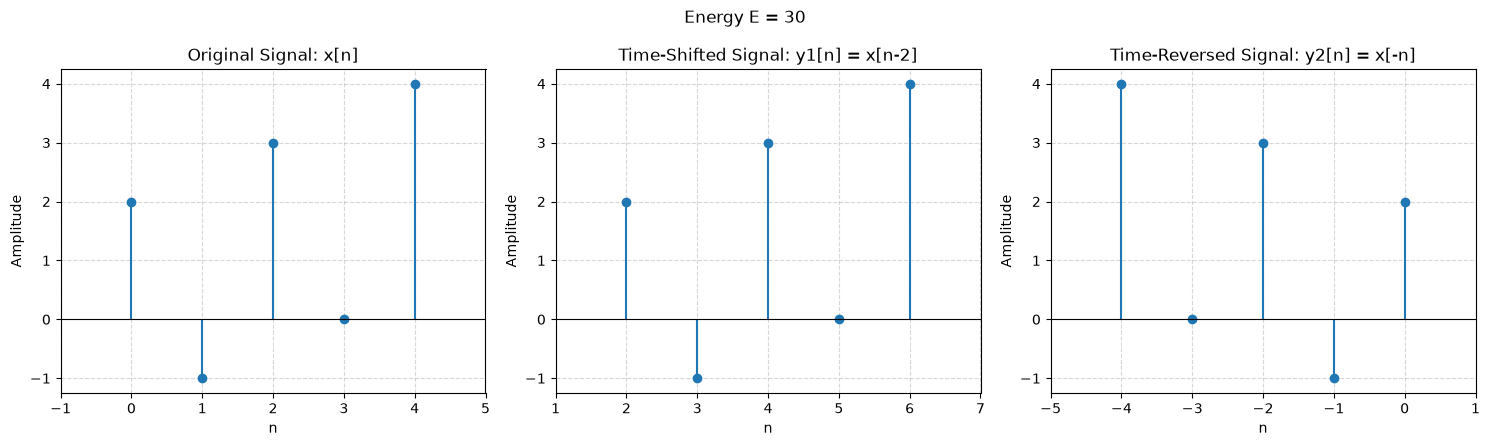

In [2]:
# Plot all three as stem diagrams
def stem_plot(ax, seq, title):
    ns = sorted(seq.keys())
    vals = [seq[n] for n in ns]
    ax.stem(ns, vals, basefmt=" ")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("n")
    ax.set_ylabel("Amplitude")
    ax.set_xticks(range(min(ns) - 1, max(ns) + 2))
    ax.grid(True, linestyle="--", alpha=0.5)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
stem_plot(axes[0], x,  "Original Signal: x[n]")
stem_plot(axes[1], y1, "Time-Shifted Signal: y1[n] = x[n-2]")
stem_plot(axes[2], y2, "Time-Reversed Signal: y2[n] = x[-n]")
fig.suptitle(f"Energy E = {E}")
plt.tight_layout()
plt.savefig("dsp_part3_diagram.png", dpi=150)
plt.show()